In [1]:
#import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
#from sklearn.preprocessing import MinMaxScaler

In [2]:
#import data matrix
fpath1 = '../esr_data/svd_matrix_sensor1/cycle1'
fpath2 = '../esr_data/svd_matrix_sensor1/cycle2'
fpath3 = '../esr_data/svd_matrix_sensor1/cycle3'

df1 = pd.read_csv(fpath1, sep=',', header=0)
df1.drop(columns= ['25 C-lower power', '15', '10', '10.1', '-30', "-20", "0"], inplace= True)

df2 = pd.read_csv(fpath2, sep=',', header=0)

df3 = pd.read_csv(fpath3, sep=',', header=0)

In [3]:
df1_cols =  ['Unnamed: 0', 'frequency', '25up', '30up', '35up', '40down', '45down',
       '50', '45', '40', '35', '30', '25', '20']

In [4]:
df2_cols = [['-30 a', '-20 a', '-10 a', '0 a',
       '10 a', '20 a', '30 a', '40 a', '50 a', '40 a', '30 a', '20 a',
       '10 a', '0 a', '-10 a', '-20 a', '-30 a']]

df3_cols = ['Unnamed: 0', 'frequency', '-30 b', '15 b', '25 b', '30 b', '40 b', '70 b', '40_1 b',
       '25_1 b', '10 b', '-30_1 b']

In [5]:
cols = ['Unnamed: 0', 'frequency', '25', '30', '35', '40', '45',
       '50', '45', '40', '35', '30', '25', '20', '-30', '-20', '-10', '0',
       '10', '20', '30', '40', '50', '40', '30', '20',
       '10', '0', '-10', '-20', '-30', '-30', '15', '25', '30', '40', '70', '40.1',
       '25.1', '10', '-30.1']

print(cols)

['Unnamed: 0', 'frequency', '25', '30', '35', '40', '45', '50', '45', '40', '35', '30', '25', '20', '-30', '-20', '-10', '0', '10', '20', '30', '40', '50', '40', '30', '20', '10', '0', '-10', '-20', '-30', '-30', '15', '25', '30', '40', '70', '40.1', '25.1', '10', '-30.1']


<AxesSubplot:>

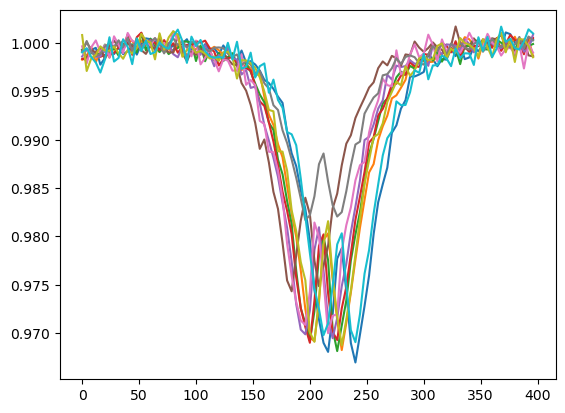

In [6]:
df3.columns = df3_cols

df3.iloc[::4, 2:].plot(legend=False)

In [7]:
df = pd.DataFrame(np.hstack([df1.values, df2.iloc[:, 2:].values, df3.iloc[::4, 2:].values]))
df.columns = cols

In [8]:
df.head()

,Unnamed: 0,frequency,25,30,35,40,45,50,45,40,...,-30,15,25,30,40,70,40.1,25.1,10,-30.1
0,0.0,2.811100e+09,0.999142,0.999478,0.998860,0.999069,1.000268,1.000011,0.999153,0.999103,...,0.999266,0.998267,0.999300,0.998360,0.998602,0.999164,0.999652,0.999081,1.000818,0.999026
1,1.0,2.812200e+09,0.999349,0.998945,0.999002,0.999313,0.999081,0.999486,0.999123,0.999814,...,0.998643,0.998666,0.998366,0.998254,0.999306,1.000081,0.997890,1.000202,0.997103,0.999464
2,2.0,2.813300e+09,0.999960,0.999258,0.999181,0.999466,0.999409,0.998929,0.999018,0.998879,...,0.999275,0.999587,0.998985,0.999402,0.999355,0.999277,0.999553,0.999055,0.998404,0.998543
3,3.0,2.814400e+09,0.999192,0.998927,0.999673,0.999554,1.000471,1.000530,0.999370,0.998231,...,0.999497,0.998015,0.998933,0.998778,0.998576,0.999026,1.000265,0.998630,0.998760,0.997978
4,4.0,2.815500e+09,0.999390,0.998538,1.000290,0.999589,0.999183,0.999337,0.999965,0.999555,...,0.997759,0.999215,0.998755,0.998565,0.998618,0.999509,0.999048,0.998884,0.999651,0.996941


In [9]:
temps = np.array([25, 30, 35, 40, 45,
       50, 45, 40, 35, 30, 25, 20, -30, -20, -10, 0,
       10, 20, 30, 40, 50, 40, 30, 20,
       10, 0, -10, -20, -30, -30, 15, 25, 30, 40, 70, 40.1,
       25.1, 10, -30.1])


In [10]:
df.drop('Unnamed: 0', axis = 1, inplace=True)

In [11]:
X = df.T

In [12]:
X.columns = X.iloc[0, :]
X.drop('frequency', axis =0, inplace=True)
X.head(2)

frequency,2.811100e+09,2.812200e+09,2.813300e+09,2.814400e+09,2.815500e+09,2.816600e+09,2.817700e+09,2.818800e+09,2.819900e+09,2.821000e+09,...,2.910100e+09,2.911200e+09,2.912300e+09,2.913400e+09,2.914500e+09,2.915600e+09,2.916700e+09,2.917800e+09,2.918900e+09,2.920000e+09
25,0.999142,0.999349,0.999960,0.999192,0.999390,0.999793,0.999249,0.999106,0.999718,0.999762,...,0.999375,0.999111,0.999511,0.999680,1.000556,1.000407,1.000181,0.999673,1.001053,1.000383
30,0.999478,0.998945,0.999258,0.998927,0.998538,0.999835,0.999599,0.998298,1.000335,0.999604,...,0.999020,0.998788,1.000922,1.000083,1.000158,0.999901,1.000401,1.000391,0.999310,1.000179


In [13]:
X.reset_index(drop=True, inplace=True)

In [14]:
X = X - X.mean()

<AxesSubplot:xlabel='frequency'>

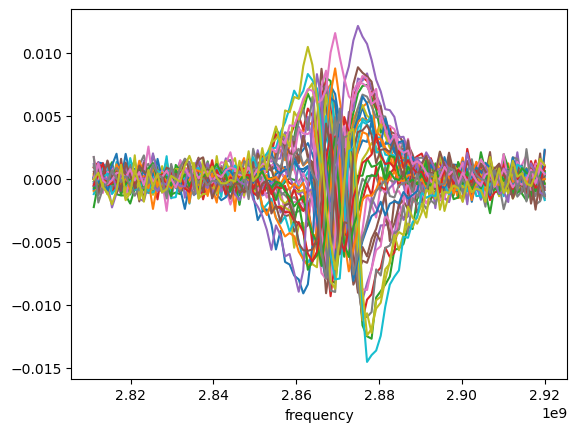

In [15]:
X.T.plot(legend=False)

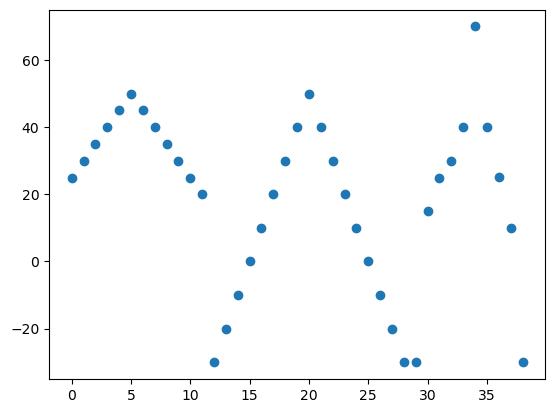

In [16]:
y = temps
plt.plot(y, 'o')


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

In [18]:
# specify the number of componenets
n_comps = 6
# # Create a Dask PCA object
pca = PCA(n_components=n_comps, svd_solver='auto')

# Fit the PCA model
pca.fit_transform(X_train) 

array([[-1.00033128e-02, -1.31026329e-02,  9.94412576e-03,
        -4.83754652e-03, -2.19815952e-03,  3.93307687e-03],
       [-3.64873398e-02,  7.67672517e-03, -8.08399528e-03,
        -2.66767199e-04,  1.75361572e-03, -5.61580925e-03],
       [ 1.33235724e-02, -8.22067748e-03, -1.05040578e-02,
         4.23134250e-03,  2.51725541e-03,  3.63440913e-03],
       [ 1.04581378e-02,  3.77225229e-03,  5.67339426e-03,
         4.02749406e-03, -8.27029057e-04, -1.20502404e-04],
       [-5.07969824e-04, -1.42056643e-02,  4.06814502e-03,
         1.57642233e-03, -2.78117074e-03, -1.72058508e-03],
       [ 9.92487050e-03,  8.78270456e-03,  1.09587149e-02,
         2.46962168e-03, -1.67530575e-03, -2.59271452e-05],
       [-1.94903344e-02, -6.91363439e-03,  5.55954715e-03,
        -8.32434093e-03,  2.50842588e-03, -8.63814854e-04],
       [ 2.19479816e-02,  1.06867732e-02, -6.34916694e-03,
        -3.16362281e-03,  2.89170372e-03, -1.51519619e-04],
       [ 7.44759496e-03,  1.33235964e-02,  1.436

In [19]:
# Get explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_


In [20]:
# export_name = '../sensor_3_modeling/cycle_1_and_2/ramp_1/sensor_3_ramp_1_split_scree_plot.png'

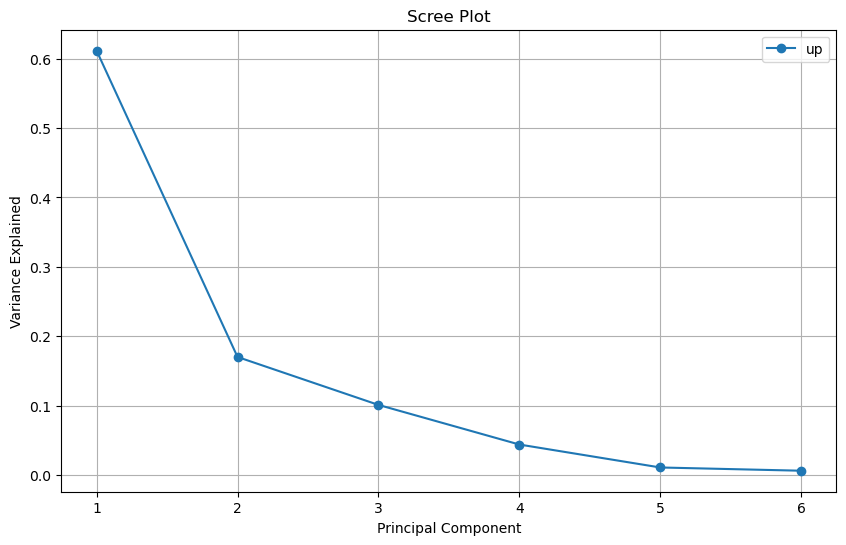

In [21]:
# Create scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.legend(['up', 'down', 'all'])
plt.grid()
#plt.savefig(export_name, dpi=700)
plt.show()

In [22]:
x_label = X.columns.astype('float')

In [23]:
# export_name = '../sensor_3_modeling/cycle_1_and_2/ramp_1/sensor_3_eigenmode_comparison_mode_{}.png'

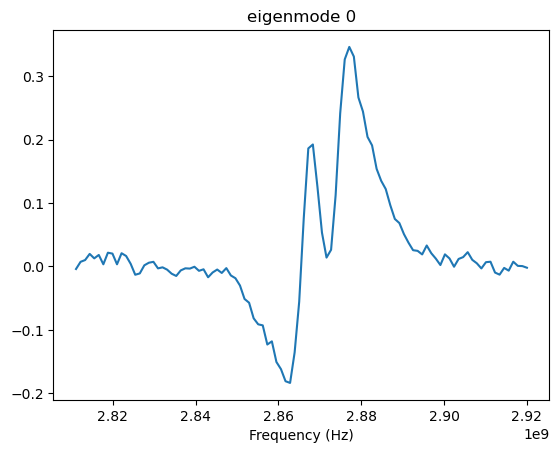

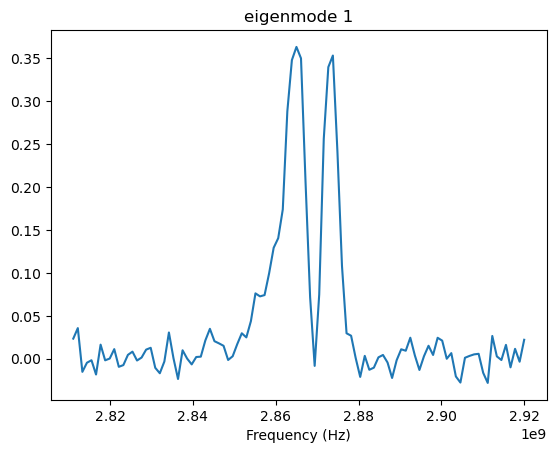

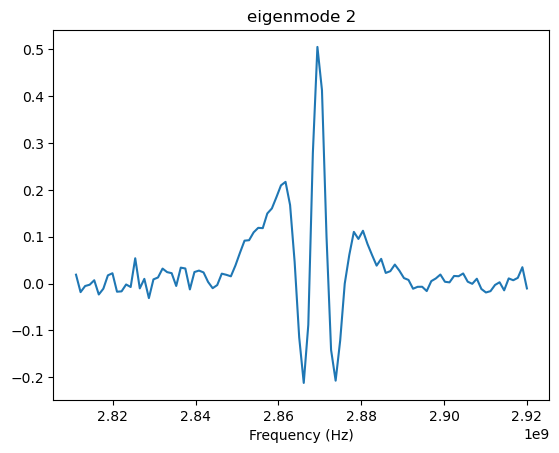

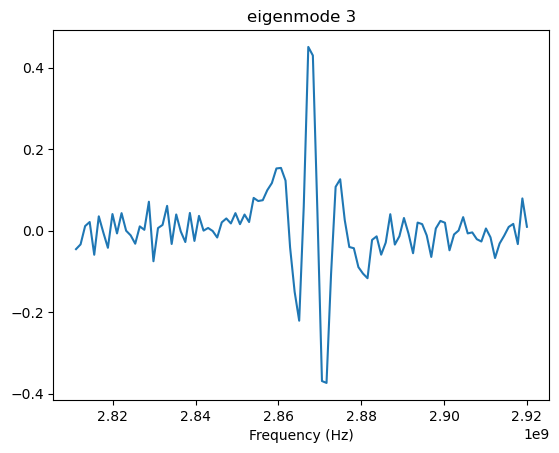

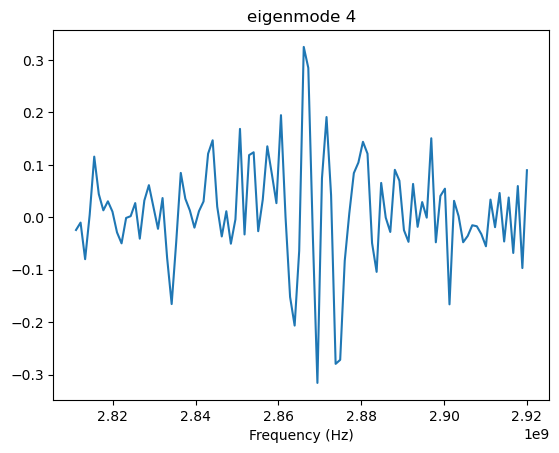

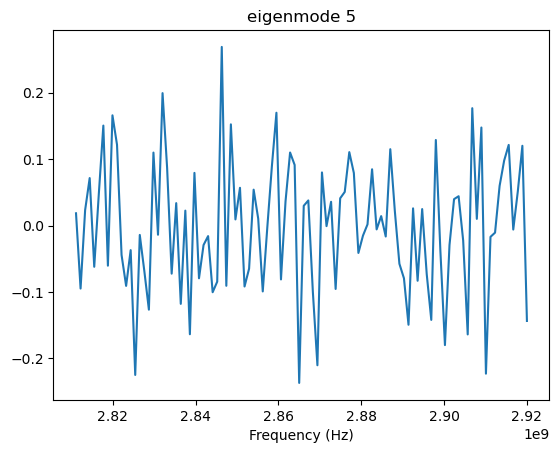

In [24]:
# plot each of the components
for i in range(n_comps):
    plt.plot(x_label.values, pca.components_.T[:,i]); 
    plt.title('eigenmode {}'.format(i))
    plt.xlabel('Frequency (Hz)')
    #plt.savefig(export_name.format(i), dpi=700)
    plt.show()

In [25]:
loadings_train = (X_train@pca.components_.T)
loadings_test = (X_test@pca.components_.T)

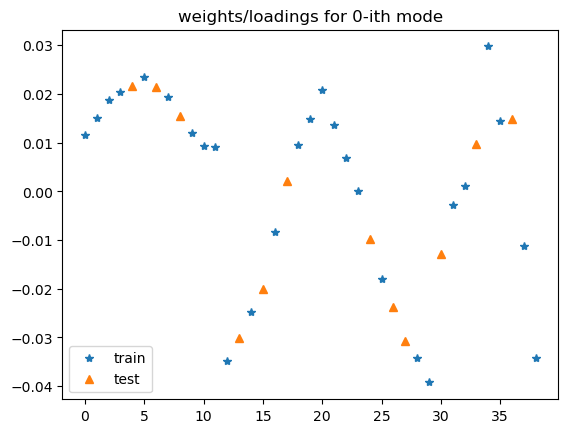

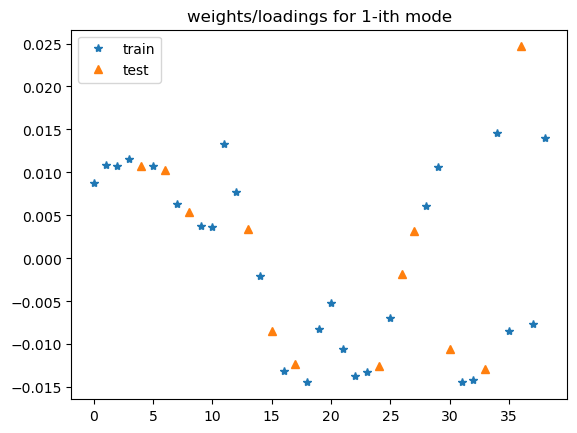

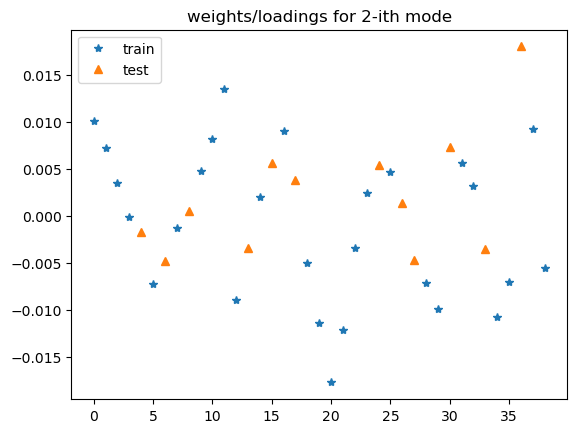

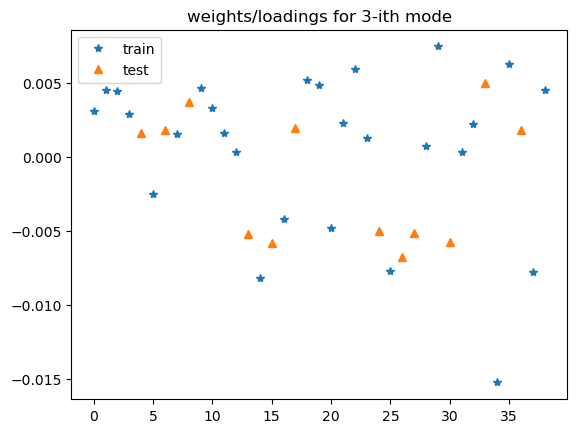

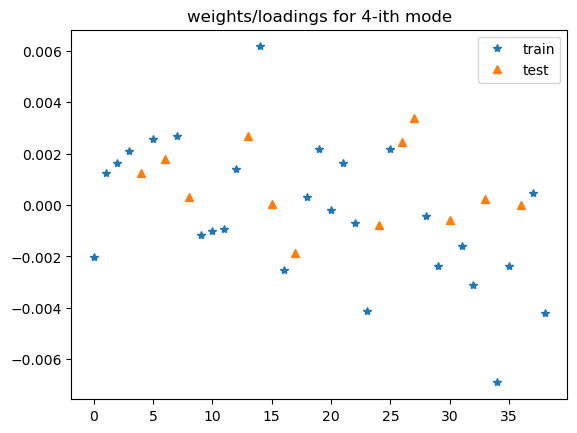

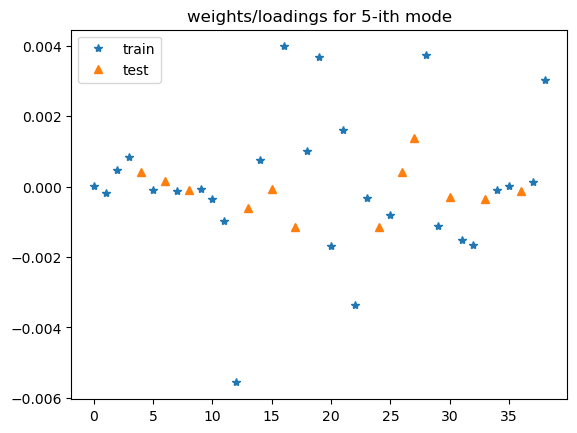

In [26]:
for i in range(n_comps):
    plt.plot(loadings_train.iloc[:, i], '*')
    plt.plot(loadings_test.iloc[:, i], '^')
    plt.legend(['train', 'test'])
    plt.title('weights/loadings for {}-ith mode'.format(i))
    #plt.savefig('../sensor_3_modeling/cycle_1_and_2/ramp_by_ramp/loadings_for_mode_{}.png'.format((i)))
    plt.show()

PErforrm linear Regression on just the first loading

In [27]:
loadings_train.iloc[:, [0,2,3,4,5]]

,0,2,3,4,5
16,-0.008439,0.009059,-0.004186,-0.002529,0.003985
12,-0.034923,-0.008969,0.000385,0.001423,-0.005564
19,0.014888,-0.011389,0.004883,0.002187,0.003686
9,0.012022,0.004788,0.004679,-0.001158,-0.000069
32,0.001056,0.003183,0.002228,-0.003112,-0.001669
0,0.011489,0.010074,0.003121,-0.002006,0.000026
25,-0.017926,0.004674,-0.007673,0.002178,-0.000812
5,0.023512,-0.007234,-0.002512,0.002561,-0.000100
11,0.009012,0.013481,0.001631,-0.000921,-0.000962
1,0.015042,0.007254,0.004534,0.001239,-0.000190


In [28]:

ln = LinearRegression()


ln.fit(loadings_train.iloc[:, [0,2,3,4,5]].values, y_train)
pred = ln.predict(loadings_test.iloc[:, [0,2,3,4,5]].values)
sq_error = mean_squared_error(y_test, pred)
print(np.sqrt(sq_error))




5.225420841193766


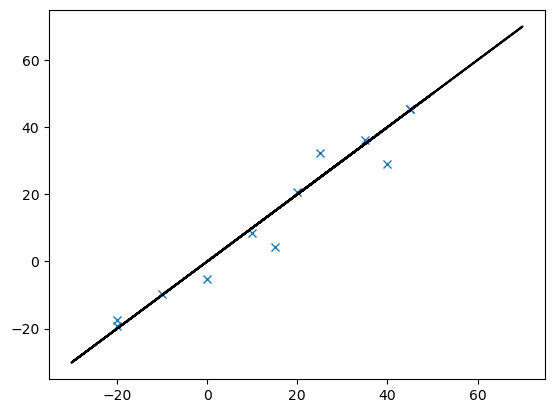

In [29]:
plt.plot(y_test, pred, 'x') 
plt.plot(y_train, y_train, 'k')

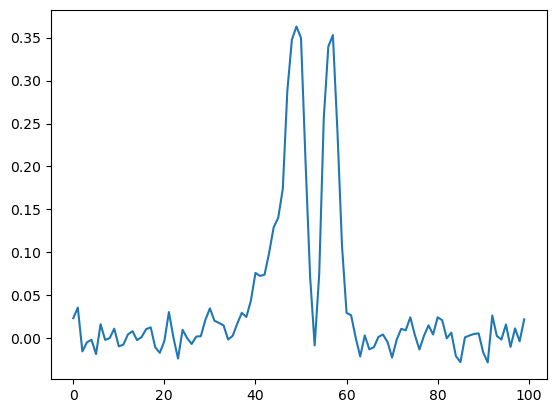

In [30]:
"""let's look at mode 2 only"""
mode2 =  pca.components_[1].T
plt.plot(mode2)

In [31]:
drift_loading = X@mode2

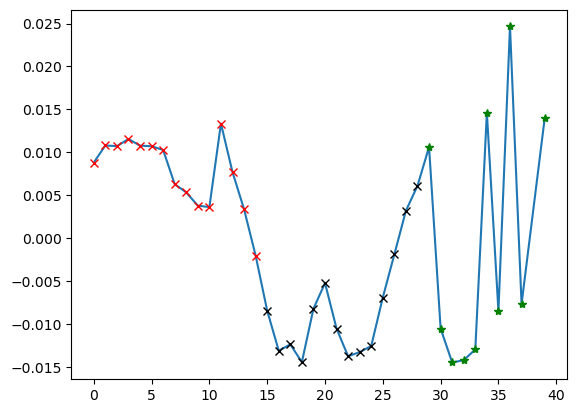

In [32]:
x = np.linspace(0, 39, num=39,dtype=int)

plt.plot(x, drift_loading.values)
plt.plot(x[:15], drift_loading[:15].values, 'rx')
plt.plot(x[15:29], drift_loading[15:29].values, 'kx')
plt.plot(x[29:], drift_loading[29:].values, 'g*')

Text(0, 0.5, 'drift loading')

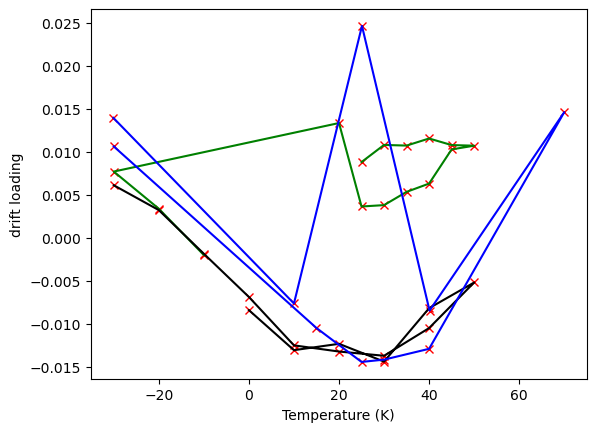

In [33]:
plt.plot(y, drift_loading.values, 'rx')
plt.plot(y[:15], drift_loading[:15].values, 'g'),
plt.plot(y[15:29], drift_loading[15:29].values, 'k'),
plt.plot(y[29:], drift_loading[29:].values, 'b'),
plt.xlabel('Temperature (K)')
plt.ylabel('drift loading')

In [34]:
pca.components_[[0,1,2,4,5],:].shape

(5, 100)

In [35]:
y_pred = ln.predict((X@pca.components_[[0,2,3,4,5], :].T))

resids = temps.reshape(1,-1) - y_pred.reshape(1,-1)

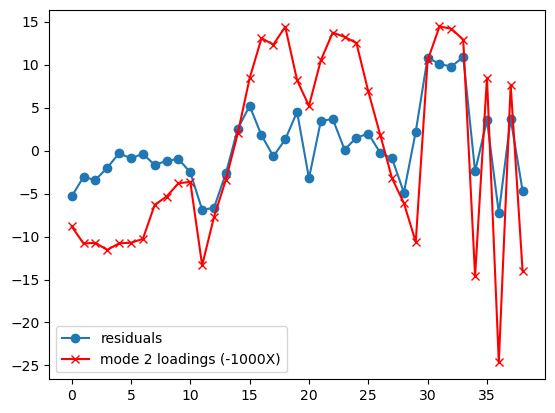

In [36]:
plt.plot(resids[0], '-o')
plt.plot(drift_loading*-1000, 'r-x')
plt.legend(['residuals', 'mode 2 loadings (-1000X)'])

Text(0, 0.5, 'residual')

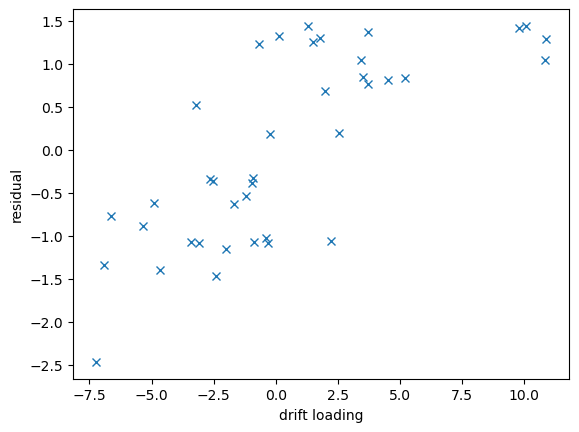

In [37]:
plt.plot(  resids[0],drift_loading.values*-100, 'x')
plt.xlabel('drift loading')
plt.ylabel('residual')
# plt.plot( drift_loading.values, resids[0])